# Phase 3 — ViRGo-SAGE: GNN encoder over the virtual graphs

**What this notebook does.** Trains an **unsupervised GraphSAGE** (`encoder.py`) on the **saved Phase-2 virtual graphs** and evaluates it on node classification + leakage-free link prediction — the Skipgram back end replaced by message passing, everything else identical.

**Separation of concerns.** `2-phase_2_virtual_graph.ipynb` _builds and tests_ the virtual graphs; this notebook only _reads_ them (`output/<dataset>/k<K>/virtual_<sim>.edgelist`) and the shared LP splits (`splits/<dataset>/<dataset>_vglp_s<seed>_*`). If they are missing, run the Phase-2 notebook first.

**Why comparable.** The loss positives come from the **same walk corpus** the Phase-2 DeepWalk bridge used (same generator, params, seeds) ⇒ Phase-2 vs Phase-3 differ in **one component only**: Skipgram's lookup table vs GraphSAGE message passing.

Design: `docs/phase3_gnn_design.md` · Spine steps: README Phase 3.


In [1]:
"""Setup: repo root, config, knobs. This notebook reads Phase-2 artifacts; it builds no graphs."""
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)                     # run everything from the repo root
sys.path[:0] = [str(Path.cwd()), str(Path.cwd() / "scripts")]

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import benchmark_config as cfg
import eval_nodeclass, eval_linkpred, results_io
from encoder import SageEncoder
from virtual_graph import VirtualGraph

DATASET = "enzymes"                                    # <-- pick the dataset (same knob as Phase 2)
SIM, K = "psi", 10                                  # <-- pick the virtual graph: sim in {psi, degree, centrality}, K in {5, 10, 20}
SEEDS = [42, 43, 44]                                # <-- pick seeds manually; keep [42, 43, 44] to match the bridge for fair comparison
POSITIVES = "edge"                                  # <-- ablation A: "walk" = A1 walk co-occurrence (like I2V) | "edge" = A2 direct virtual edges
P = cfg.GNN_PARAMS                                  # single source of truth (scripts/benchmark_config.py) - loads GNN settings
FORCE_REBUILD = False                               # False = reuse saved .emb if present

TAG = "sage" if POSITIVES == "walk" else "sage_edge"                 # file prefix: A2 files never overwrite the A1 spine
ENCODER = "graphsage" if POSITIVES == "walk" else "graphsage_edge"   # name in the comparison table + scoreboard
print(f"dataset={DATASET}  sim={SIM}  K={K}  seeds={SEEDS}  positives={POSITIVES} ({ENCODER})")
print(P)

dataset=enzymes  sim=psi  K=10  seeds=[42, 43, 44]  positives=edge (graphsage_edge)
{'hidden': 64, 'dimensions': 64, 'layers': 2, 'agg': 'mean', 'lr': 0.01, 'epochs': 50, 'negatives': 5, 'pairs_per_epoch': 100000, 'max_pairs': 2000000, 'positives': 'walk'}


/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load the graphs

Original graph from `input/` (node set + structural features); **saved** virtual graph from Phase 2. No building here — missing file ⇒ run the Phase-2 notebook.


In [2]:
"""Load original graph + the SAVED Phase-2 virtual graph."""
G = nx.read_edgelist(cfg.dataset(DATASET)["edgelist"], nodetype=int, create_using=nx.Graph())

vpath = Path("output") / DATASET / f"k{K}" / f"virtual_{SIM}.edgelist"
assert vpath.exists(), f"{vpath} missing -> run notebooks/2-phase_2_virtual_graph.ipynb first (it builds + saves the virtual graphs)"
V = nx.read_weighted_edgelist(vpath, nodetype=int)
V.add_nodes_from(G.nodes)                           # edgelists omit isolated nodes -> restore the full node set
print(f"original: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges")
print(f"virtual({SIM}, K={K}): {V.number_of_nodes()} nodes / {V.number_of_edges()} edges  <- {vpath}")

original: 19474 nodes / 37282 edges
virtual(psi, K=10): 19474 nodes / 111401 edges  <- output/enzymes/k10/virtual_psi.edgelist


## 2 · Train the graph (full graph → NC embeddings)

Per seed: structural features X = [degree, Ω, ψ, clustering] from the **original** graph → 2-layer mean GraphSAGE over the **virtual** edges → Skipgram-analog loss (deg^0.75 negatives, Q=5) → `output/<dataset>/k<K>/<tag>_nc_<sim>_s<seed>.emb`. Reuse-or-create, like every other stage.

**Ablation A (the `POSITIVES` knob in Setup):** `"walk"` (A1) = positives from walk co-occurrence on the virtual graph, exactly the Phase-2 bridge corpus — the fair Skipgram-vs-GNN comparison. `"edge"` (A2) = positives are the virtual edges themselves, no walks — simpler, tests whether walks are still needed once similarity is explicit. A2 files get the `sage_edge_` prefix so the two never overwrite each other.


In [3]:
"""Train ViRGo-SAGE per seed on the full virtual graph; reuse saved .emb when present."""
losses = None
for seed in SEEDS:
    out = Path("output") / DATASET / f"k{K}" / f"{TAG}_nc_{SIM}_s{seed}.emb"
    if out.exists() and not FORCE_REBUILD:
        print(f"reuse {out}")
        continue
    print(f"train seed {seed} ({POSITIVES} positives) ...")
    enc = SageEncoder(G, V, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"])
    losses = enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                       pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
    enc.save(out)
    print(f"saved {out}")

if losses:                                          # spine check: the loss must fall
    plt.figure(figsize=(5, 3))
    plt.plot(losses)
    plt.xlabel("epoch"); plt.ylabel("skipgram-analog loss"); plt.title(f"ViRGo-SAGE  {DATASET}  {SIM}  K={K}  {POSITIVES}")
    plt.tight_layout(); plt.show()

reuse output/enzymes/k10/sage_edge_nc_psi_s42.emb
reuse output/enzymes/k10/sage_edge_nc_psi_s43.emb
reuse output/enzymes/k10/sage_edge_nc_psi_s44.emb


## 3 · Verify the Embeddings

Every node embedded · all values finite · file readable by the same gensim loader the eval scripts use (README Phase-3 step 5).


In [4]:
"""Spine checks: node count, finiteness, loader compatibility."""
from gensim.models import KeyedVectors
for seed in SEEDS:
    out = Path("output") / DATASET / f"k{K}" / f"{TAG}_nc_{SIM}_s{seed}.emb"
    kv = KeyedVectors.load_word2vec_format(str(out))
    assert len(kv) == G.number_of_nodes(), f"{out.name}: {len(kv)} vectors != {G.number_of_nodes()} nodes"
    assert np.isfinite(kv.vectors).all(), f"{out.name}: non-finite values"
    print(f"PASS {out.name}: {len(kv)} nodes x {kv.vectors.shape[1]}d, finite")

PASS sage_edge_nc_psi_s42.emb: 19474 nodes x 64d, finite
PASS sage_edge_nc_psi_s43.emb: 19474 nodes x 64d, finite
PASS sage_edge_nc_psi_s44.emb: 19474 nodes x 64d, finite


## 4 · Node classification (weighted F1)

Same protocol as Phase 2 / I2V: one-vs-rest logistic regression on the embeddings, stratified 70/30, per seed.


In [5]:
"""Node classification on the SAGE embeddings — protocol identical to Phase 2."""
labels = cfg.dataset(DATASET)["labels"]
nc_rows = []
if labels is None or not Path(labels).exists():
    print(f"{DATASET}: no labels -> node classification skipped")
else:
    for seed in SEEDS:
        emb = Path("output") / DATASET / f"k{K}" / f"{TAG}_nc_{SIM}_s{seed}.emb"
        f1s, n, c = eval_nodeclass.evaluate(str(emb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
        nc_rows.append({"encoder": ENCODER, "sim": SIM, "K": K, "seed": seed, "task": "nodeclass", "metric": f1s["weighted"]})
        print(f"seed {seed}: weighted F1 = {f1s['weighted']:.4f}  (n={n}, classes={c})")
    vals = [r["metric"] for r in nc_rows]
    print(f"\nNC weighted F1 = {np.mean(vals):.4f} ± {np.std(vals):.4f}")

seed 42: weighted F1 = 0.5428  (n=19474, classes=3)
seed 43: weighted F1 = 0.5409  (n=19474, classes=3)
seed 44: weighted F1 = 0.5401  (n=19474, classes=3)

NC weighted F1 = 0.5413 ± 0.0011


## 5 · Link prediction (AUC, leakage-free)

Reuses the **same** Phase-2 splits (`<dataset>_vglp_s<seed>_*`) for a fair encoder comparison. Per seed: read the 70% train edgelist → deterministically rebuild the train virtual graph (same `VirtualGraph` builder) → train SAGE on it → score held-out edges. Nothing from the 30% test edges touches training.


In [6]:
"""Leakage-free LP: same Phase-2 splits, train-virtual rebuilt from the 70% edges, SAGE trained on it."""
sdir = Path("splits") / DATASET
lp_rows = []
for seed in SEEDS:
    name = f"{DATASET}_vglp_s{seed}"
    train_edges = sdir / f"{name}_train.edgelist"
    assert train_edges.exists(), f"{train_edges} missing -> run the Phase-2 notebook LP section first (shared splits = fair comparison)"
    emb = Path("output") / DATASET / f"k{K}" / f"{TAG}_lp_{SIM}_s{seed}.emb"
    if not emb.exists() or FORCE_REBUILD:
        print(f"train LP seed {seed} ({POSITIVES} positives) ...")
        Gt = nx.read_edgelist(train_edges, nodetype=int, create_using=nx.Graph())
        Vt = VirtualGraph(Gt).build(SIM, K)               # deterministic rebuild from the 70% train edges only
        enc = SageEncoder(Gt, Vt, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"])
        enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                  pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
        enc.save(emb)
    else:
        print(f"reuse {emb}")
    auc = eval_linkpred.evaluate(str(emb), str(sdir), name, seed=seed, score=cfg.REPRO["linkpred_score"])
    lp_rows.append({"encoder": ENCODER, "sim": SIM, "K": K, "seed": seed, "task": "linkpred", "metric": auc})
    print(f"seed {seed}: AUC = {auc:.4f}")
vals = [r["metric"] for r in lp_rows]
print(f"\nLP AUC = {np.mean(vals):.4f} ± {np.std(vals):.4f}")

reuse output/enzymes/k10/sage_edge_lp_psi_s42.emb
seed 42: AUC = 0.6920
reuse output/enzymes/k10/sage_edge_lp_psi_s43.emb
seed 43: AUC = 0.7093
reuse output/enzymes/k10/sage_edge_lp_psi_s44.emb
seed 44: AUC = 0.6713

LP AUC = 0.6909 ± 0.0156


## 6 · Final comparison — DeepWalk (Phase 2) vs GraphSAGE (Phase 3)

**One table, one row per task.** Both encoders are scored **right here, the same way**, from their saved embedding files in `output/<dataset>/k<K>/` — `vg_*` (Phase-2 DeepWalk bridge) and `sage_*` (Phase-3 GraphSAGE) — on the same virtual graph, same splits, same seeds. No dependency on any Phase-2 CSV, so the numbers always match the knobs set in Setup.

- **`improvement`** = GraphSAGE − DeepWalk (positive = the GNN is better).
- **`winner`** = which encoder scored higher on that task.

If an embedding file is missing, the cell says exactly which notebook to run. Table saved to `results/vir_graph_variants/<dataset>_encoder_comparison_K<K>.csv`.


In [7]:
"""One final table: DeepWalk (Phase 2) vs GraphSAGE (Phase 3), both scored here from their saved embeddings."""
labels = cfg.dataset(DATASET)["labels"]
have_labels = labels is not None and Path(labels).exists()
sdir = Path("splits") / DATASET
NC, LP = "node classification (weighted F1)", "link prediction (AUC)"

def task_scores(tag, notebook):
    """Score one encoder's saved .emb files with the shared eval protocol -> {task: [score per seed]}."""
    got = {NC: [], LP: []}
    for seed in SEEDS:
        emb = {kind: Path("output") / DATASET / f"k{K}" / f"{tag}_{kind}_{SIM}_s{seed}.emb" for kind in ("nc", "lp")}
        if have_labels:
            assert emb["nc"].exists(), f"{emb['nc']} missing -> run {notebook} with the same DATASET/SIM/K/SEEDS first"
            f1s, _, _ = eval_nodeclass.evaluate(str(emb["nc"]), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
            got[NC].append(f1s["weighted"])
        assert emb["lp"].exists(), f"{emb['lp']} missing -> run {notebook} with the same DATASET/SIM/K/SEEDS first"
        got[LP].append(eval_linkpred.evaluate(str(emb["lp"]), str(sdir), f"{DATASET}_vglp_s{seed}", seed=seed, score=cfg.REPRO["linkpred_score"]))
    return got

bridge = task_scores("vg", "notebooks/2-phase_2_virtual_graph.ipynb (sections 7-8)")
sage = task_scores(TAG, "sections 2-5 above (same POSITIVES knob)")

comp = pd.DataFrame([{"task": t,
                      "deepwalk_phase2": round(float(np.mean(bridge[t])), 4),
                      f"{ENCODER}_phase3": round(float(np.mean(sage[t])), 4),
                      "improvement": round(float(np.mean(sage[t]) - np.mean(bridge[t])), 4),
                      "winner": ENCODER if np.mean(sage[t]) > np.mean(bridge[t]) else "deepwalk"}
                     for t in (NC, LP) if sage[t]])
out = Path("results") / "vir_graph_variants"; out.mkdir(parents=True, exist_ok=True)
suffix = "" if POSITIVES == "walk" else f"_{POSITIVES}"              # A2 snapshot never overwrites the A1 snapshot
comp_csv = out / f"{DATASET}_encoder_comparison_K{K}{suffix}.csv"
comp.to_csv(comp_csv, index=False)
print(f"{DATASET} | virtual graph: {SIM}, K={K} | positives: {POSITIVES} | seeds: {SEEDS} | same graph, same splits — only the encoder differs")
print(f"saved -> {comp_csv}")
display(comp)

for enc_name, got in (("deepwalk", bridge), (ENCODER, sage)):   # every run also lands in the accumulating scoreboard
    for t in (NC, LP):
        if got[t]:
            results_io.record_score(DATASET, enc_name, SIM, K, t, SEEDS, got[t])
print("recorded -> results/vir_graph_variants/scoreboard.csv  (section 7 shows every variant tested so far)")

enzymes | virtual graph: psi, K=10 | positives: edge | seeds: [42, 43, 44] | same graph, same splits — only the encoder differs
saved -> results/vir_graph_variants/enzymes_encoder_comparison_K10_edge.csv


,task,deepwalk_phase2,graphsage_edge_phase3,improvement,winner
0,node classification (weighted F1),0.4971,0.5413,0.0441,graphsage_edge
1,link prediction (AUC),0.5110,0.6909,0.1799,graphsage_edge


recorded -> results/vir_graph_variants/scoreboard.csv  (section 7 shows every variant tested so far)


## 7 · Scoreboard — every variant tested so far

Section 6 records each run into **`results/vir_graph_variants/scoreboard.csv`** — one row per _dataset × encoder × graph variant × top-K × task_, **updated in place**: rerunning the same knobs refreshes that row, new knobs add a new row, nothing is ever lost.

**Column meanings:** `graph_variant` = how the virtual graph was built (`psi` = I2V's Poisson/KL similarity, `degree` = degree-only, `centrality` = eigenvector-centrality-only) · `top_K_neighbors` = how many most-similar nodes each node was connected to (the K knob) · `seeds` = which random seeds the mean/std cover.

**Workflow:** change `SIM` / `K` / `SEEDS` / `DATASET` in Setup → run the Phase-2 notebook for that variant (builds the graph + bridge embeddings) → rerun §1–6 here → come back to this section: the table and charts below grow with every variant, so "which virtual graph is best, and does the GNN beat the walk?" is answered at a glance.


,encoder,graph_variant,top_K_neighbors,task,seeds,mean,std,variant
0,graphsage_edge,psi,10,link prediction (AUC),42|43|44,0.6909,0.0156,psi K=10
1,graphsage,psi,10,link prediction (AUC),42|43|44,0.6632,0.0114,psi K=10
2,deepwalk,psi,10,link prediction (AUC),42|43|44,0.5110,0.0297,psi K=10
3,graphsage_edge,psi,10,node classification (weighted F1),42|43|44,0.5413,0.0011,psi K=10
4,graphsage,psi,10,node classification (weighted F1),42|43|44,0.5405,0.0014,psi K=10
5,deepwalk,psi,10,node classification (weighted F1),42|43|44,0.4971,0.0057,psi K=10


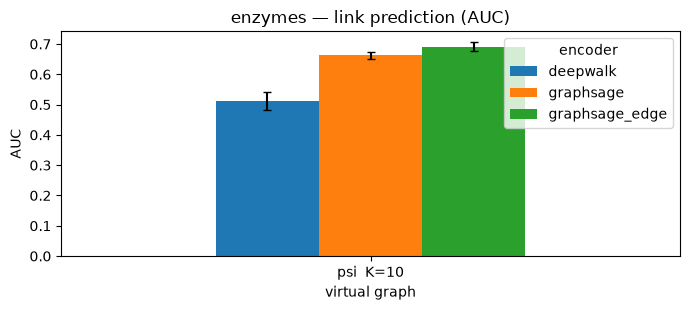

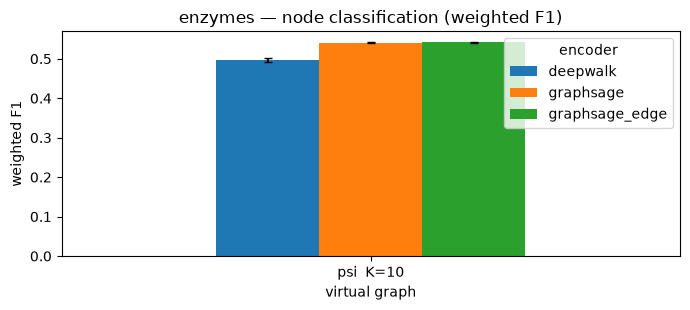

In [8]:
"""Scoreboard: full table for this dataset + one comparison chart per task (bars = variants, colors = encoders)."""
sb = Path("results") / "vir_graph_variants" / "scoreboard.csv"
assert sb.exists(), f"{sb} missing -> run section 6 once first (it records the scores)"
board = pd.read_csv(sb)
b = board[board["dataset"] == DATASET].copy()
b["variant"] = b["graph_variant"] + "  K=" + b["top_K_neighbors"].astype(str)
display(b.drop(columns="dataset").sort_values(["task", "mean"], ascending=[True, False]).reset_index(drop=True))

for task in sorted(b["task"].unique()):
    t = b[b["task"] == task]
    means = t.pivot_table(index="variant", columns="encoder", values="mean")
    stds = t.pivot_table(index="variant", columns="encoder", values="std")
    ax = means.plot.bar(yerr=stds, figsize=(7, 3.2), rot=0, capsize=3, title=f"{DATASET} — {task}")
    ax.set_xlabel("virtual graph"); ax.set_ylabel(task.split("(")[-1].rstrip(")"))
    plt.tight_layout(); plt.show()

## 8 · Status + next

- **Spine (this notebook):** SAGE trained + evaluated end-to-end on the saved virtual graphs; §6 head-to-head vs the bridge, §7 accumulating scoreboard.
- **Stage 1 (current):** lock the encoder — **A** positives implemented (`POSITIVES` knob: A1 `"walk"` vs A2 `"edge"`); run both, then **B** aggregation (mean vs Ψ-weighted) next.
- **Stage 2:** winning config × {Ψ, degree, centrality} × K {5, 10, 20} — "which virtual graph?" under the GNN (fills the §7 scoreboard).
- **Stage 3:** depth / feature ablations + original-graph control row.

Run settings live in `scripts/benchmark_config.py` (`GNN_PARAMS`); design in `docs/phase3_gnn_design.md`.
